# История Казахстана — QA-бот · Fine-tuning (Unsloth + Llama-3.1-8B)

Дообучение модели отвечать на вопросы по истории Казахстана (11 класс).
Pipeline: **OCR (Surya) → QA-генерация (gpt-5-mini) → SFT QLoRA (Unsloth) → evaluation**.

**How to run on Google Colab (GPU T4):**
1. Upload `book.pdf` and this file to the Colab session.
2. Provide secrets via a local `.env` or Colab secrets: `OPENAI_API_KEY`, `HF_TOKEN`
   (optional `HF_USERNAME` to enable Hub push + Trackio Space).
3. `pip install jupytext` then `jupytext --to notebook history_finetuning.py`.
4. Open the generated `.ipynb` → **Runtime → Run all** → save the notebook WITH outputs.

Style follows the studied template (Unsloth path only). Every deviation is marked

# 1. INSTALL DEPENDENCIES

In [1]:
# Purpose: install the data + Unsloth training stack (Colab T4), pinned for a REPRODUCIBLE run.
# CHANGED: installs run via subprocess (not `!uv pip ...`) so this file stays valid Python
#          (jupytext converts it cleanly, `python -m py_compile` passes).
# CHANGED (reproducibility): Unsloth + unsloth_zoo are now installed from PyPI at PINNED versions
#          instead of git `main`. git main moves daily, so a re-run could silently pull a newer
#          Unsloth with a different API — that is what caused the SFTTrainer `tokenizer=` →
#          `processing_class=` break and the `<EOS_TOKEN>` failure on re-runs.
# NOTE: every pin below is mutually compatible with unsloth==2026.6.9's own dependency ranges:
#          transformers==4.56.2  (allowed; also what Qwen2.5-VL OCR and trl 0.22.2 need)
#          bitsandbytes==0.49.2  (unsloth EXCLUDES 0.46.0 and 0.48.0 — the old 0.48.0 pin conflicted)
#          trl==0.22.2           (allowed; our SFTConfig/SFTTrainer code targets this API)
#          torch>=2.8,<2.11      (unsloth requires torch<2.11.0)
#          unsloth_zoo==2026.6.7 (matches unsloth 2026.6.9's `unsloth_zoo>=2026.6.7`)
# ============================================================
import subprocess
import sys


def sh(cmd: str) -> None:
    """Run a shell command, echoing it first (Colab/notebook friendly)."""
    print(f"$ {cmd}")
    subprocess.run(cmd, shell=True, check=True)


# Common libraries (data generation, datasets, metrics, plotting).
sh(
    f"{sys.executable} -m pip install -q "
    "openai datasets huggingface_hub accelerate "
    "evaluate rouge_score sacrebleu nltk bert_score pandas tqdm "
    "matplotlib python-dotenv"
)
# Core training stack — versions ALLOWED by unsloth==2026.6.9 (see notes above).
sh(
    f"{sys.executable} -m pip install -q "
    '"torch>=2.8.0,<2.11.0" "triton>=3.4.0" torchvision '
    "bitsandbytes==0.49.2 transformers==4.56.2"
)
# TRL without deps, BEFORE Unsloth, so Unsloth sees its trl requirement already satisfied
# by 0.22.2 (in range) and does not pull a newer trl that would upgrade transformers.
sh(f"{sys.executable} -m pip install -q --no-deps trl==0.22.2")
# Unsloth — PINNED from PyPI (reproducible), NOT git main. All its deps are already satisfied.
sh(f"{sys.executable} -m pip install -q unsloth==2026.6.9 unsloth_zoo==2026.6.7")
print("Dependencies installed.")

$ /usr/bin/python3 -m pip install -q openai datasets huggingface_hub accelerate evaluate rouge_score sacrebleu nltk bert_score pandas tqdm matplotlib python-dotenv
$ /usr/bin/python3 -m pip install -q "torch>=2.8.0,<2.11.0" "triton>=3.4.0" torchvision bitsandbytes==0.49.2 transformers==4.56.2
$ /usr/bin/python3 -m pip install -q --no-deps trl==0.22.2
$ /usr/bin/python3 -m pip install -q unsloth==2026.6.9 unsloth_zoo==2026.6.7
Dependencies installed.


# 2. IMPORTS + ENVIRONMENT CHECK

In [2]:
# CHANGED: Unsloth-only subset (dropped AutoModelForCausalLM / BitsAndBytesConfig /
#          LoraConfig / PeftModel / ORPO imports from the template).
# ============================================================
import os
import gc
import json
import re
from pathlib import Path

# ADDED: silence noisy warnings so the Colab "Run all" output stays readable.
import warnings
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# CRITICAL (unsloth #2797): import Unsloth BEFORE trl / transformers / peft. Unsloth patches those
# libraries on import; if trl is imported first, Unsloth overwrites SFTConfig's eos_token with the
# '<EOS_TOKEN>' sentinel (not in the Llama vocab) and SFTTrainer then crashes. Unsloth first = fixed.
from unsloth import FastLanguageModel  # Unsloth optimized loader/trainer — MUST be imported first

import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

from openai import OpenAI
from datasets import Dataset
from huggingface_hub import login
from trl import SFTTrainer, SFTConfig
import evaluate

try:                                    # ADDED: quiet transformers logging
    from transformers.utils import logging as hf_logging
    hf_logging.set_verbosity_error()
except Exception:
    pass

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"BF16 supported: {torch.cuda.is_bf16_supported()}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
BF16 supported: False


# 3. PROJECT CONFIGURATION  (all knobs in one place — template style)

In [3]:
CONFIG = {
    # ---- Hugging Face ----
    # CHANGED: set your username here, or put HF_USERNAME in .env / Colab secrets.
    "hf_username": 'timkaiyr',
    "dataset_name": "kz-history-qa-dataset",
    "model_name": "kz-history-qa-llama3.1-8b",

    # ---- Base model ----
    # CHANGED: Llama-3.1-8B (Unsloth 4-bit, T4-friendly, not gated).
    "base_model_unsloth": "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit",

    # ---- Dataset generation (gpt-5-mini) ----
    "openai_generation_model": "gpt-5-mini",
    "num_examples": 330,          # CHANGED: 300+ target (dedupe lands >=300)
    "chunk_size": 1500,           # chars of OCR text per generation call
    "chunk_overlap": 150,

    # ---- Training ----
    "num_epochs": 3,
    "batch_size": 2,
    "gradient_accumulation": 4,
    "learning_rate": 2e-4,
    "max_length": 1024,           # CHANGED: 8B on T4 (template used 2048)

    # ---- LoRA ----
    "lora_r": 16,
    "lora_alpha": 16,             # CHANGED: alpha=r (Unsloth norm; template used 32)
    "lora_dropout": 0,            # 0 = fastest for Unsloth

    # ---- OCR (Section 5) ----
    "pdf_path": "/content/sample_data/book.pdf",
    "page_start": 3,              # printed page numbers, inclusive
    "page_end": 23,
    "ocr_dpi": 300,

    # ---- Output paths ----
    "text_path": "history_text.txt",             # spec deliverable
    "dataset_path": "history_sft_dataset.json",  # spec deliverable
    "output_dir": "./sft_output",
    "local_model_dir": "./kz_history_qa_lora",

    # ---- Hub push (user choice: auto-push, public) ----
    "push_to_hub": True,          # CHANGED
    "hub_public": True,           # CHANGED
}

DATASET_REPO = f"{CONFIG['hf_username']}/{CONFIG['dataset_name']}"
MODEL_REPO = f"{CONFIG['hf_username']}/{CONFIG['model_name']}"

# Guard: only push / sync to a real account (skip the placeholder).
HF_READY = CONFIG["hf_username"] not in ("", "YOUR_HF_USERNAME")
DO_PUSH = CONFIG["push_to_hub"] and HF_READY
if CONFIG["push_to_hub"] and not HF_READY:
    print("WARNING: hf_username is a placeholder — Hub push/Trackio-Space disabled. "
          "Set HF_USERNAME to enable.")

print(f"Dataset repo: {DATASET_REPO}")
print(f"Model repo:   {MODEL_REPO}")

# Automatic precision (T4 -> fp16; bf16-capable GPUs -> bf16).
USE_BF16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
USE_FP16 = torch.cuda.is_available() and not USE_BF16
print(f"USE_BF16={USE_BF16}  USE_FP16={USE_FP16}")

Dataset repo: timkaiyr/kz-history-qa-dataset
Model repo:   timkaiyr/kz-history-qa-llama3.1-8b
USE_BF16=False  USE_FP16=True


In [4]:
import os
p = CONFIG["pdf_path"]                 # uses the same path the OCR step uses
print("path:    ", p)
print("exists:  ", os.path.exists(p))
if os.path.exists(p):
    print("size:    ", os.path.getsize(p), "bytes")
    with open(p, "rb") as f:
        head = f.read(5)
    print("PDF header:", head, "->", "valid PDF" if head == b"%PDF-" else "NOT a PDF")

path:     /content/sample_data/book.pdf
exists:   True
size:     36159857 bytes
PDF header: b'%PDF-' -> valid PDF


# 4. LOGINS / SECRETS

In [5]:
# CHANGED: read keys from Colab Secrets via google.colab.userdata
#          (userdata.get('OPENAI_API_KEY') for OpenAI, userdata.get('HF_TOKEN')
#          for Hugging Face), with a local .env / env-var fallback.
# ============================================================
def get_secret(name: str):
    """Colab Secrets first (userdata.get), then a local .env / environment variable."""
    try:
        from google.colab import userdata          # Colab Secrets (🔑 panel)
        val = userdata.get(name)
        if val:
            return val
    except Exception:
        pass
    try:
        from dotenv import load_dotenv
        load_dotenv()                                # loads .env if present (local dev)
    except Exception:
        pass
    return os.environ.get(name)


OPENAI_API_KEY = get_secret("OPENAI_API_KEY")        # Colab: userdata.get('OPENAI_API_KEY')
HF_TOKEN = get_secret("HF_TOKEN")                    # Colab: userdata.get('HF_TOKEN')

assert OPENAI_API_KEY, "OPENAI_API_KEY missing (add it to Colab Secrets or .env)"
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY
if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN
    login(HF_TOKEN)
    print("Hugging Face: logged in.")
else:
    print("HF_TOKEN missing — Hub features will be skipped.")

client = OpenAI()
print("OpenAI client ready.")

Hugging Face: logged in.
OpenAI client ready.


# 5. OCR — Qwen2.5-VL-7B (4-bit vision-LLM) -> history_text.txt

In [6]:
# CHANGED: a vision-LLM reads each page WITH CONTEXT, so Roman-numeral centuries (XI, XV),
#          dates, Kazakh and English come out right (plain EasyOCR-ru dropped Latin letters
#          -> wrong dates). Runs in the MAIN env — Qwen2.5-VL needs transformers>=4.49 and
#          our pinned stack is 4.56.2 (compatible). Use Qwen2.5-VL, NOT Qwen3-VL (needs
#          >=4.57). Loaded 4-bit, used for OCR, then FREED before training (Section 9).
# FALLBACK: a proven EasyOCR main-env path is kept commented at the end of this cell.
# ============================================================
OCR_PROMPT = (
    "Извлеки весь основной текст с этой страницы учебника истории Казахстана (11 класс) "
    "в правильном порядке чтения. Римские цифры (века, например XI, XV), даты и числа "
    "перепиши ТОЧНО как в оригинале. Включай казахские и английские слова. Пропусти "
    "колонтитулы, номера страниц и водяные знаки. Ничего не переводи и не добавляй от себя."
)
OCR_RENDER_DPI = 150          # moderate DPI -> bounded vision tokens (avoids T4 OOM)

text_path = Path(CONFIG["text_path"])
if text_path.exists() and text_path.stat().st_size > 0:
    print(f"{text_path} already exists — skipping OCR (delete it to re-run).")
else:
    assert Path(CONFIG["pdf_path"]).exists(), (
        f"PDF not found at {CONFIG['pdf_path']} — upload book.pdf and fix CONFIG['pdf_path']."
    )
    sh(f"{sys.executable} -m pip install -q pymupdf")
    import fitz                                   # PyMuPDF — render pages to images
    from PIL import Image
    from unsloth import FastVisionModel

    # Pre-quantized 4-bit Qwen2.5-VL — ~5 GB, ungated; only model loaded at this point.
    ocr_model, ocr_proc = FastVisionModel.from_pretrained(
        "unsloth/Qwen2.5-VL-7B-Instruct-bnb-4bit", load_in_4bit=True,
    )
    FastVisionModel.for_inference(ocr_model)

    def render_page(page, dpi):
        m = fitz.Matrix(dpi / 72, dpi / 72)
        pix = page.get_pixmap(matrix=m, alpha=False)
        img = Image.frombytes("RGB", (pix.width, pix.height), pix.samples)
        if max(img.size) > 1600:                  # safety cap on vision tokens / VRAM
            img.thumbnail((1600, 1600))
        return img

    doc = fitz.open(CONFIG["pdf_path"])
    page_texts = []
    for i in range(CONFIG["page_start"] - 1, CONFIG["page_end"]):   # printed pages -> 0-indexed
        img = render_page(doc[i], OCR_RENDER_DPI)
        messages = [{"role": "user",
                     "content": [{"type": "image"}, {"type": "text", "text": OCR_PROMPT}]}]
        prompt = ocr_proc.apply_chat_template(messages, add_generation_prompt=True)
        inputs = ocr_proc(text=[prompt], images=[img], return_tensors="pt").to(ocr_model.device)
        gen = ocr_model.generate(**inputs, max_new_tokens=2048, do_sample=False, use_cache=True)
        new = gen[0][inputs["input_ids"].shape[1]:]
        page_texts.append(ocr_proc.decode(new, skip_special_tokens=True).strip())
        print(f"[OCR] page {i + 1} -> {len(page_texts[-1])} chars")
    doc.close()

    history_text = "\n\n".join(p for p in page_texts if p.strip())
    text_path.write_text(history_text, encoding="utf-8")
    print(f"[OCR] saved {text_path} ({len(history_text)} chars)")

    # Free the VLM before training (a T4 can't hold the VLM + Llama-8B at once).
    del ocr_model, ocr_proc
    gc.collect()
    torch.cuda.empty_cache()

history_text = text_path.read_text(encoding="utf-8")
print(f"\nOCR text length: {len(history_text)} chars")
print("----- OCR fragment -----")
print(history_text[:600])

# --- FALLBACK: EasyOCR in the main env (proven to work, but weaker on Roman numerals/Kazakh)
#     — uncomment + delete history_text.txt and re-run this cell if Qwen2.5-VL errors. ----------
# sh(f"{sys.executable} -m pip install -q easyocr pymupdf")
# import fitz, easyocr
# _NOISE = re.compile(r"(OKULYK\.KZ|Приказа Министра)", re.I)
# _reader = easyocr.Reader(["ru"], gpu=torch.cuda.is_available())
# def _render(page, dpi):
#     m = fitz.Matrix(dpi / 72, dpi / 72); pix = page.get_pixmap(matrix=m, alpha=False)
#     return np.frombuffer(pix.samples, np.uint8).reshape(pix.height, pix.width, 3)
# _doc = fitz.open(CONFIG["pdf_path"]); _parts = []
# for _i in range(CONFIG["page_start"] - 1, CONFIG["page_end"]):
#     _lines = _reader.readtext(_render(_doc[_i], CONFIG["ocr_dpi"]), detail=0, paragraph=True)
#     _parts.append("\n".join(s.strip() for s in _lines if s.strip() and not _NOISE.search(s)))
# _doc.close()
# text_path.write_text("\n\n".join(p for p in _parts if p.strip()), encoding="utf-8")
# history_text = text_path.read_text(encoding="utf-8"); print(history_text[:600])

history_text.txt already exists — skipping OCR (delete it to re-run).

OCR text length: 33577 chars
----- OCR fragment -----
Все учебники Казахстана на OKULYK.KZ

РАЗДЕЛ III
РАЗВИТИЕ ОБЩЕСТВЕННО-ПОЛИТИЧЕСКОЙ МЫСЛИ
Шестая глава
ЭВОЛЮЦИЯ ОБЩЕСТВЕННО-ПОЛИТИЧЕСКОЙ МЫСЛИ КАЗАХСТАНА

§23–24. Истоки и развитие общественно-политической мысли

Цели обучения:
✓ определить общественно-политические идеи исторических личностей древнего и средневекового Казахстана;
✓ оценить вклад исторических деятелей в развитие общественно-политической мысли Казахстана.

Ключевые слова:

| По-русски | По-казахски | По-английски |
|-----------|-------------|--------------|
| Древние тюрки | Ежелгі түркілер | Ancient turks |
| Суфизм | Солысық | 


# 6. QA GENERATION (gpt-5-mini) -> grounded {question, answer} pairs

In [7]:
# CHANGED: generate factual QA grounded in the OCR text (template made fan/neutral pairs
#          for ORPO — dropped). gpt-5-mini params kept minimal (no custom temperature;
#          uses max_completion_tokens; strict JSON; defensive parse).
# ============================================================
GENERATION_PROMPT = """Ты — эксперт по истории Казахстана (учебник, 11 класс).
На основе ТЕКСТА ниже составь {n} разных пар "вопрос-ответ" для обучения модели.

ТЕКСТ:
\"\"\"{context}\"\"\"

Требования:
- Вопросы РАЗНЫХ типов: "Кто такой...?", "Что написал...?", "В каком веке...?",
  "Что такое...?", "Какое значение имеет...?".
- Ответы краткие (1-3 предложения), на русском, основаны ТОЛЬКО на тексте.
- Не выдумывай факты, которых нет в тексте.
- Даты, века (римские цифры, напр. XI, XV) и числа указывай ТОЧНО как в тексте,
  не меняй и не округляй их.
- Если факт неоднозначен, противоречив или текст в этом месте испорчен —
  ПРОПУСТИ его, не угадывай.

Верни СТРОГО JSON: {{"pairs": [{{"question": "...", "answer": "..."}}]}}
"""


def generate_qa_batch(context: str, n: int) -> list:
    """Ask gpt-5-mini for n grounded QA pairs; return [] on a bad/empty response."""
    resp = client.chat.completions.create(
        model=CONFIG["openai_generation_model"],
        messages=[{"role": "user",
                   "content": GENERATION_PROMPT.format(n=n, context=context)}],
        response_format={"type": "json_object"},
        max_completion_tokens=4000,  # CHANGED: gpt-5 family uses max_completion_tokens
    )
    try:
        return json.loads(resp.choices[0].message.content).get("pairs", [])
    except (json.JSONDecodeError, TypeError):
        return []


def chunk_text(text: str, size: int, overlap: int) -> list:
    text = re.sub(r"[ \t]+", " ", text).strip()
    out, i = [], 0
    while i < len(text):
        out.append(text[i:i + size])
        i += max(1, size - overlap)
    return out


dataset_path = Path(CONFIG["dataset_path"])
if dataset_path.exists() and dataset_path.stat().st_size > 0:
    print(f"{dataset_path} exists — loading it (delete to regenerate).")
    sft_data_existing = json.loads(dataset_path.read_text(encoding="utf-8"))
    qa_pairs = [{"question": m["messages"][1]["content"],
                 "answer": m["messages"][2]["content"]} for m in sft_data_existing]
else:
    chunks = chunk_text(history_text, CONFIG["chunk_size"], CONFIG["chunk_overlap"])
    per_chunk = max(6, CONFIG["num_examples"] // max(1, len(chunks)) + 3)  # overshoot
    print(f"{len(chunks)} chunks x ~{per_chunk} pairs -> target {CONFIG['num_examples']}+")

    raw = []
    for ch in tqdm(chunks, desc="Generating QA"):
        if len(raw) >= CONFIG["num_examples"] + 40:
            break
        raw.extend(generate_qa_batch(ch, per_chunk))

    # Deduplicate by normalized question; keep valid non-empty pairs.
    seen, qa_pairs = set(), []
    for p in raw:
        q = (p.get("question") or "").strip()
        a = (p.get("answer") or "").strip()
        key = q.lower()
        if q and a and key not in seen:
            seen.add(key)
            qa_pairs.append({"question": q, "answer": a})
    print(f"QA pairs after dedup: {len(qa_pairs)}")

print("----- sample QA pairs -----")
print(json.dumps(qa_pairs[:3], ensure_ascii=False, indent=2))

history_sft_dataset.json exists — loading it (delete to regenerate).
----- sample QA pairs -----
[
  {
    "question": "Чьё творческое наследие оказало влияние на ученых Востока и общественно-политическую мысль средневековой Западной Европы?",
    "answer": "Творческое наследие аль-Фараби."
  },
  {
    "question": "Что проявляют творческое наследие аль-Фараби?",
    "answer": "Поиск и стремление к достижению человеком совершенства."
  },
  {
    "question": "Какой труд аль-Фараби наиболее известен?",
    "answer": "«Трактат о взглядах жителей добродетельного города»."
  }
]


# 7. CONVERT TO SFT CHAT FORMAT -> save history_sft_dataset.json (spec deliverable)

In [8]:
SYSTEM_PROMPT = ("Ты — помощник по истории Казахстана. "
                 "Отвечай кратко и точно на основе школьного учебника (11 класс).")

sft_data = [
    {"messages": [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": p["question"]},
        {"role": "assistant", "content": p["answer"]},
    ]}
    for p in qa_pairs
]

dataset_path.write_text(json.dumps(sft_data, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"SFT examples: {len(sft_data)}  ->  saved {dataset_path}")
print(json.dumps(sft_data[0], ensure_ascii=False, indent=2))

SFT examples: 218  ->  saved history_sft_dataset.json
{
  "messages": [
    {
      "role": "system",
      "content": "Ты — помощник по истории Казахстана. Отвечай кратко и точно на основе школьного учебника (11 класс)."
    },
    {
      "role": "user",
      "content": "Чьё творческое наследие оказало влияние на ученых Востока и общественно-политическую мысль средневековой Западной Европы?"
    },
    {
      "role": "assistant",
      "content": "Творческое наследие аль-Фараби."
    }
  ]
}


# 8. HUGGING FACE DATASET + TRAIN/TEST SPLIT

In [9]:
dataset = Dataset.from_list(sft_data)
split = dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split["train"]
eval_dataset = split["test"]
print(f"Train: {len(train_dataset)}  Eval: {len(eval_dataset)}")

Train: 196  Eval: 22


# 9. LOAD MODEL (Unsloth)

In [10]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=CONFIG["base_model_unsloth"],
    max_seq_length=CONFIG["max_length"],
    load_in_4bit=True,
)
print(f"Loaded: {CONFIG['base_model_unsloth']}")

==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Loaded: unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit


# 10. FORMAT DATASET FOR TRAINING (chat template -> "text")

In [11]:
def format_for_training(example):
    text = tokenizer.apply_chat_template(
        example["messages"], tokenize=False, add_generation_prompt=False,
    )
    return {"text": text}


train_dataset = train_dataset.map(format_for_training)
eval_dataset = eval_dataset.map(format_for_training)
print(train_dataset[0]["text"][:500])

Map:   0%|          | 0/196 [00:00<?, ? examples/s]

Map:   0%|          | 0/22 [00:00<?, ? examples/s]

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024

Ты — помощник по истории Казахстана. Отвечай кратко и точно на основе школьного учебника (11 класс).<|eot_id|><|start_header_id|>user<|end_header_id|>

Какую обязанность возложили на старейшин по тексту Гавердовского?<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Им возложили непосредственную обязанность отвечать перед ханом за все возможные в родах беспорядки и с


# 11. APPLY LoRA (Unsloth)

In [12]:
model = FastLanguageModel.get_peft_model(
    model,
    r=CONFIG["lora_r"],
    lora_alpha=CONFIG["lora_alpha"],
    lora_dropout=CONFIG["lora_dropout"],
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,} ({100 * trainable / total:.2f}%)")

Trainable: 41,943,040 / 4,582,543,360 (0.92%)


# 12. TRAINING CONFIG (SFTConfig) + Trackio

In [13]:
# CHANGED: optim="adamw_8bit" (low VRAM); report_to="none" — Trackio was DROPPED because
#          its latest release needs huggingface_hub>=1.0, which conflicts with the pinned
#          transformers==4.56.2. The matplotlib loss curve in Section 14 shows the loss.
# ============================================================
# CHANGED: Unsloth/TRL can leave the sentinel '<EOS_TOKEN>' on BOTH the tokenizer AND SFTConfig.
#          TRL 0.22.2 only validates args.eos_token when it is not None, and Unsloth's patched
#          SFTConfig defaults it to '<EOS_TOKEN>' (not in the vocab) -> SFTTrainer raises. Force a
#          real, in-vocab EOS (Llama-3.1 = <|eot_id|>) onto the tokenizer UNCONDITIONALLY and pass
#          that literal to SFTConfig below, so the sentinel can never reach the trainer.
EOS_TOKEN = next((t for t in ("<|eot_id|>", "<|end_of_text|>")
                  if tokenizer.convert_tokens_to_ids(t) is not None), tokenizer.eos_token)
tokenizer.eos_token = EOS_TOKEN
tokenizer.eos_token_id = tokenizer.convert_tokens_to_ids(EOS_TOKEN)
print(f"EOS token: {tokenizer.eos_token} (id={tokenizer.eos_token_id})")

training_args = SFTConfig(
    output_dir=CONFIG["output_dir"],
    num_train_epochs=CONFIG["num_epochs"],
    per_device_train_batch_size=CONFIG["batch_size"],
    per_device_eval_batch_size=CONFIG["batch_size"],
    gradient_accumulation_steps=CONFIG["gradient_accumulation"],
    learning_rate=CONFIG["learning_rate"],
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    optim="adamw_8bit",          # CHANGED: low-VRAM optimizer
    weight_decay=0.01,
    logging_steps=5,
    report_to="none",            # CHANGED: Trackio dropped (dep conflict); loss via Section 14
    eval_strategy="steps",
    eval_steps=25,
    save_strategy="steps",
    save_steps=50,
    save_total_limit=2,
    bf16=USE_BF16,
    fp16=USE_FP16,
    max_length=CONFIG["max_length"],
    dataset_text_field="text",
    # CHANGED: pass the real EOS explicitly so it overrides Unsloth's '<EOS_TOKEN>' sentinel default.
    eos_token=EOS_TOKEN,
    seed=42,
    # CHANGED: single explicit push AFTER training (Section 15) instead of pushing
    # adapter+card at every save_steps — avoids mid-training network stalls / partial
    # checkpoint pushes on Colab.
    push_to_hub=False,
)
print("Training config ready.")

EOS token: <|eot_id|> (id=128009)
Training config ready.


# 13. CREATE TRAINER (Unsloth) — LoRA already applied, so no peft_config.

In [14]:
# CHANGED: newer TRL removed the `tokenizer=` argument — pass `processing_class=tokenizer`
#          instead (older TRL used `tokenizer=`). dataset_text_field and max_length already
#          live in SFTConfig above.
# ============================================================
# CHANGED: Unsloth's patched SFTConfig re-injects the '<EOS_TOKEN>' sentinel in post-init, which
#          OVERRIDES anything passed to SFTConfig(eos_token=...). Fix it on the config OBJECT here
#          — after construction, right before SFTTrainer reads it. Use a real in-vocab token
#          (Llama-3.1 = <|eot_id|>), or None to make TRL skip its eos_token vocab check entirely.
_eos = next((t for t in ("<|eot_id|>", "<|end_of_text|>")
             if tokenizer.convert_tokens_to_ids(t) is not None), None)
if _eos:
    tokenizer.eos_token = _eos
training_args.eos_token = _eos
print(f"EOS -> config={training_args.eos_token!r}, tokenizer={tokenizer.eos_token!r} "
      f"(id={tokenizer.eos_token_id})")

trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    args=training_args,
)
print("SFTTrainer ready.")

EOS -> config='<|eot_id|>', tokenizer='<|eot_id|>' (id=128009)


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/196 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/22 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
SFTTrainer ready.


# 14. TRAIN  (+ ADDED: matplotlib loss curve from trainer.state.log_history)

Effective batch size: 8
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!
{'loss': 3.5456, 'grad_norm': 2.3198916912078857, 'learning_rate': 0.0001, 'epoch': 0.20408163265306123}
{'loss': 2.066, 'grad_norm': 1.908638596534729, 'learning_rate': 0.00019989008914857116, 'epoch': 0.40816326530612246}
{'loss': 1.1119, 'grad_norm': 0.80625319480896, 'learning_rate': 0.000196068518757684, 'epoch': 0.6122448979591837}
{'loss': 1.0155, 'grad_norm': 1.1456326246261597, 'learning_rate': 0.00018699063724087904, 'epoch': 0.8163265306122449}
{'loss': 0.8541, 'grad_norm': 2.0316057205200195, 'learning_rate': 0.0001731531335263669, 'epoch': 1.0}
{'eval_loss': 0.7733016610145569, 'eval_runtime': 4.3333, 'eval_samples_per_second': 5.077, 'eval_steps_per_second': 2.538, 'epoch': 1.0}
{'loss': 0.7063, 'grad_norm': 0.7925209403038025, 'learning_rate': 0.00015531311541251995, 'epoch': 1.2040816326530612}
{'loss': 0.6447, 'grad

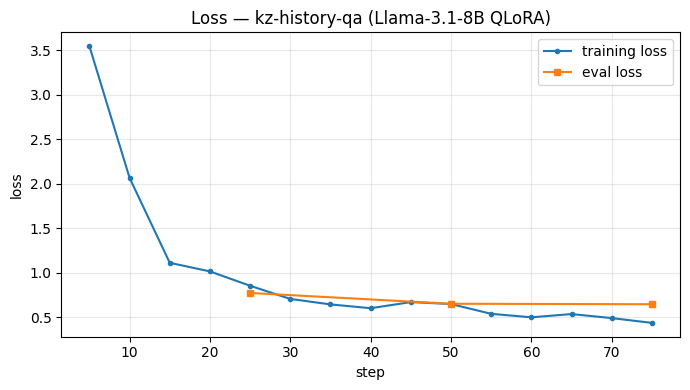

In [15]:
print(f"Effective batch size: {CONFIG['batch_size'] * CONFIG['gradient_accumulation']}")
train_result = trainer.train()
print(f"Training finished. Final training loss: {train_result.training_loss:.4f}")

# ADDED: static loss curve from the training log history (primary "loss decreases" evidence).
# Overlays training loss and eval loss on the same axes (eval rows use the key "eval_loss").
train_logs = [h for h in trainer.state.log_history if "loss" in h]
eval_logs = [h for h in trainer.state.log_history if "eval_loss" in h]
if train_logs:
    plt.figure(figsize=(7, 4))
    plt.plot([h["step"] for h in train_logs], [h["loss"] for h in train_logs],
             marker="o", ms=3, label="training loss")
    if eval_logs:
        plt.plot([h["step"] for h in eval_logs], [h["eval_loss"] for h in eval_logs],
                 marker="s", ms=4, label="eval loss")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("Loss — kz-history-qa (Llama-3.1-8B QLoRA)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("loss_curve.png", dpi=120)
    plt.show()

# 15. SAVE MODEL  (+ optional Hub push — public, per user choice)

In [16]:
trainer.save_model(CONFIG["local_model_dir"])
tokenizer.save_pretrained(CONFIG["local_model_dir"])
print(f"Saved LoRA adapter locally: {CONFIG['local_model_dir']}")

if DO_PUSH:
    model.push_to_hub(MODEL_REPO, private=not CONFIG["hub_public"])
    tokenizer.push_to_hub(MODEL_REPO, private=not CONFIG["hub_public"])
    split.push_to_hub(DATASET_REPO, private=not CONFIG["hub_public"])

    # ADDED (hf-cli skill): overwrite the bare auto-generated README with explicit,
    # informative cards (model + dataset). Russian, no AI-authorship attribution.
    from huggingface_hub import HfApi
    api = HfApi()
    model_card = f"""---
license: llama3.1
language: ru
base_model: {CONFIG['base_model_unsloth']}
library_name: peft
pipeline_tag: question-answering
tags:
- unsloth
- qlora
- kazakhstan-history
---

# {CONFIG['model_name']}

QLoRA-адаптер для `{CONFIG['base_model_unsloth']}`, дообученной отвечать на вопросы
по истории Казахстана (школьный учебник, 11 класс) на русском языке.

## Данные
- Источник: OCR страниц учебника.
- Датасет: {len(sft_data)} пар «вопрос–ответ» — `{DATASET_REPO}`.

## Обучение
- Метод: SFT + QLoRA (Unsloth), 4-bit.
- Эпохи: {CONFIG['num_epochs']}; learning rate: {CONFIG['learning_rate']}; max_length: {CONFIG['max_length']}.
- LoRA: r={CONFIG['lora_r']}, alpha={CONFIG['lora_alpha']}, dropout={CONFIG['lora_dropout']}.

## Использование
Загрузите базовую модель в 4-bit и примените адаптер через PEFT.
"""
    dataset_card = f"""---
language: ru
task_categories:
- question-answering
size_categories:
- n<1K
tags:
- kazakhstan-history
---

# {CONFIG['dataset_name']}

{len(sft_data)} пар «вопрос–ответ» по истории Казахстана (11 класс), полученных по
OCR-тексту учебника. Формат — chat (system / user / assistant); сплит train/test 90/10.
"""
    api.upload_file(path_or_fileobj=model_card.encode("utf-8"),
                    path_in_repo="README.md", repo_id=MODEL_REPO, repo_type="model")
    api.upload_file(path_or_fileobj=dataset_card.encode("utf-8"),
                    path_in_repo="README.md", repo_id=DATASET_REPO, repo_type="dataset")
    # CHANGED: OCR source text is now PUBLIC too — ship it inside the dataset repo.
    api.upload_file(path_or_fileobj=CONFIG["text_path"],
                    path_in_repo="history_text.txt", repo_id=DATASET_REPO, repo_type="dataset")
    print(f"Pushed model:   https://huggingface.co/{MODEL_REPO}")
    print(f"Pushed dataset: https://huggingface.co/datasets/{DATASET_REPO}")
else:
    print("Hub push skipped (set HF_USERNAME + HF_TOKEN to enable).")

Saved LoRA adapter locally: ./kz_history_qa_lora


README.md:   0%|          | 0.00/949 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          |  557kB /  168MB            

...

New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|##########| 4.92kB / 4.92kB            

README.md:   0%|          | 0.00/376 [00:00<?, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.


Pushed model:   https://huggingface.co/timkaiyr/kz-history-qa-llama3.1-8b
Pushed dataset: https://huggingface.co/datasets/timkaiyr/kz-history-qa-dataset


# 16. EVALUATION CONFIGURATION

In [17]:
EVAL_CONFIG = {
    "system_prompt": SYSTEM_PROMPT,
    "max_new_tokens": 256,
    "temperature": 0.7,
    "top_p": 0.9,
    "do_sample": False,      # deterministic -> stable metrics
    "bertscore_lang": "ru",
    "eval_json_path": "evaluation_results.json",
    "eval_csv_path": "evaluation_answers.csv",
}
print("Eval config ready.")

Eval config ready.


# 17. TEST QUESTIONS + REFERENCES

In [18]:
# CHANGED: references come from the held-out eval split (not hardcoded). The spec's
#          questions are always shown qualitatively in Section 19.
# ============================================================
SPEC_QUESTIONS = [
    "Кто такой Махмуд Кашгари?",
    "Какую книгу написал Юсуф Баласагуни?",
    "Что такое Кутадгу билиг?",
    "Кто такой Ходжа Ахмед Яссауи?",
    "Какой вклад внёс аль-Фараби?",   # extra -> ensures >=5 answers
]

# Held-out questions/references for automatic metrics.
eval_questions = [m["messages"][1]["content"] for m in eval_dataset]
reference_answers = [m["messages"][2]["content"] for m in eval_dataset]
print(f"Spec questions: {len(SPEC_QUESTIONS)} | held-out eval: {len(eval_questions)}")

Spec questions: 5 | held-out eval: 22


# 18. PREPARE FINE-TUNED MODEL FOR INFERENCE

In [19]:
FastLanguageModel.for_inference(model)
model.eval()
print("Fine-tuned model ready for inference.")

Fine-tuned model ready for inference.


# 19a. UNIFIED GENERATION FUNCTION + GENERATE FINE-TUNED ANSWERS

In [20]:
def generate_response(model, tokenizer, question,
                      system_prompt=EVAL_CONFIG["system_prompt"],
                      max_new_tokens=EVAL_CONFIG["max_new_tokens"],
                      temperature=EVAL_CONFIG["temperature"],
                      top_p=EVAL_CONFIG["top_p"],
                      do_sample=EVAL_CONFIG["do_sample"]):
    """Generate an answer with the model's chat template (Unsloth or base)."""
    messages = [{"role": "system", "content": system_prompt},
                {"role": "user", "content": question}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    input_len = inputs["input_ids"].shape[1]

    kwargs = {"max_new_tokens": max_new_tokens, "do_sample": do_sample,
              "pad_token_id": tokenizer.eos_token_id}
    if do_sample:
        kwargs["temperature"] = temperature
        kwargs["top_p"] = top_p

    with torch.no_grad():
        out = model.generate(**inputs, **kwargs)
    return tokenizer.decode(out[0][input_len:], skip_special_tokens=True).strip()

print("=== Spec questions (qualitative) ===")
for q in SPEC_QUESTIONS:
    print(f"Q: {q}\nA: {generate_response(model, tokenizer, q)}\n" + "-" * 80)

print("Generating answers for the held-out eval set (for metrics)...")
finetuned_answers = [generate_response(model, tokenizer, q) for q in tqdm(eval_questions)]
print(f"Generated {len(finetuned_answers)} fine-tuned answers.")

=== Spec questions (qualitative) ===
Q: Кто такой Махмуд Кашгари?
A: Тюркский философ, лингвист и путешественник, автор труда «Дивани лугат ат-тюрк».
--------------------------------------------------------------------------------
Q: Какую книгу написал Юсуф Баласагуни?
A: «Дивани хикмет».
--------------------------------------------------------------------------------
Q: Что такое Кутадгу билиг?
A: Совет, содержащий рекомендации по морально-нравственному поведению.
--------------------------------------------------------------------------------
Q: Кто такой Ходжа Ахмед Яссауи?
A: Великий мыслитель, философ и правовед, который жил в XI веке.
--------------------------------------------------------------------------------
Q: Какой вклад внёс аль-Фараби?
A: Он оставил богатое наследство в области философии, политической теории и социологии.
--------------------------------------------------------------------------------
Generating answers for the held-out eval set (for metrics)...


100%|██████████| 22/22 [00:52<00:00,  2.37s/it]

Generated 22 fine-tuned answers.


# 20. METRICS (ROUGE / BLEU / BERTScore)

In [22]:
rouge = evaluate.load("rouge")
bleu_metric = evaluate.load("sacrebleu")
bertscore = evaluate.load("bertscore")


# CHANGED: rouge_score's DEFAULT tokenizer lowercases then drops every non-[a-z0-9] char, so it
#          erases Cyrillic and ROUGE comes out 0 for Russian. HF `evaluate` WRAPS the `tokenizer=`
#          argument and calls it as tokenizer(text), so it must be a plain CALLABLE (not an object
#          with .tokenize). This Unicode word tokenizer keeps Cyrillic so Russian scores correctly.
def ru_rouge_tokenizer(text):
    return re.findall(r"\w+", text.lower())

def calculate_text_metrics(predictions, references):
    r = rouge.compute(predictions=predictions, references=references,
                      tokenizer=ru_rouge_tokenizer, use_stemmer=False)   # CHANGED: Cyrillic-aware
    b = bleu_metric.compute(predictions=predictions, references=[[x] for x in references],
                            tokenize="intl")                             # CHANGED: Unicode tokenization
    bs = bertscore.compute(predictions=predictions, references=references,
                           lang=EVAL_CONFIG["bertscore_lang"])
    return {
        "ROUGE-1": round(r["rouge1"] * 100, 2),
        "ROUGE-2": round(r["rouge2"] * 100, 2),
        "ROUGE-L": round(r["rougeL"] * 100, 2),
        "BLEU": round(b["score"], 2),
        "BERTScore-F1": round(float(np.mean(bs["f1"])) * 100, 2),
    }


finetuned_metrics = calculate_text_metrics(finetuned_answers, reference_answers)
print("Fine-tuned metrics:", finetuned_metrics)

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Fine-tuned metrics: {'ROUGE-1': np.float64(20.18), 'ROUGE-2': np.float64(6.05), 'ROUGE-L': np.float64(19.12), 'BLEU': 3.67, 'BERTScore-F1': 73.46}


# 21. BASE MODEL EVALUATION (reload base for comparison)

In [23]:
# CHANGED: free the fine-tuned model first (T4 VRAM).
# ============================================================
del model
gc.collect()
torch.cuda.empty_cache()

base_model, base_tokenizer = FastLanguageModel.from_pretrained(
    model_name=CONFIG["base_model_unsloth"],
    max_seq_length=CONFIG["max_length"],
    load_in_4bit=True,
)
FastLanguageModel.for_inference(base_model)
base_model.eval()

base_answers = [generate_response(base_model, base_tokenizer, q) for q in tqdm(eval_questions)]
base_metrics = calculate_text_metrics(base_answers, reference_answers)
print("Base metrics:", base_metrics)

==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


100%|██████████| 22/22 [01:44<00:00,  4.76s/it]


Base metrics: {'ROUGE-1': np.float64(13.05), 'ROUGE-2': np.float64(4.72), 'ROUGE-L': np.float64(12.49), 'BLEU': 1.92, 'BERTScore-F1': 69.22}


# 22. COMPARE BASE vs FINE-TUNED

In [24]:
rows = []
for k in finetuned_metrics:
    rows.append({"Metric": k, "Base": base_metrics[k],
                 "Fine-tuned": finetuned_metrics[k],
                 "Delta": round(finetuned_metrics[k] - base_metrics[k], 2)})
comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))
avg_improvement = round(float(np.mean([r["Delta"] for r in rows])), 2)
print(f"\nAverage improvement: {avg_improvement:+.2f}")

      Metric  Base  Fine-tuned  Delta
     ROUGE-1 13.05       20.18   7.13
     ROUGE-2  4.72        6.05   1.33
     ROUGE-L 12.49       19.12   6.63
        BLEU  1.92        3.67   1.75
BERTScore-F1 69.22       73.46   4.24

Average improvement: +4.22


# 23. SAVE EVALUATION RESULTS + CLEAN UP

In [25]:
# ============================================================
pd.DataFrame({
    "question": eval_questions,
    "reference_answer": reference_answers,
    "base_answer": base_answers,
    "finetuned_answer": finetuned_answers,
}).to_csv(EVAL_CONFIG["eval_csv_path"], index=False, encoding="utf-8-sig")

Path(EVAL_CONFIG["eval_json_path"]).write_text(json.dumps({
    "model": MODEL_REPO,
    "dataset": DATASET_REPO,
    "base_model": CONFIG["base_model_unsloth"],
    "num_eval_samples": len(eval_questions),
    "finetuned_metrics": finetuned_metrics,
    "base_metrics": base_metrics,
    "average_improvement": avg_improvement,
    "training": {k: CONFIG[k] for k in ("num_epochs", "learning_rate", "lora_r", "lora_alpha")},
}, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"Saved {EVAL_CONFIG['eval_json_path']} and {EVAL_CONFIG['eval_csv_path']}")

del base_model
gc.collect()
torch.cuda.empty_cache()
print("Done. Remember: save the notebook WITH outputs before submitting.")

Saved evaluation_results.json and evaluation_answers.csv
Done. Remember: save the notebook WITH outputs before submitting.
